# Finger Health Status LSTM Classifier
**Classes**: Healthy | Moderate | Bad  
**Model**: Bidirectional LSTM  
**Features**: 22 sensor features (no gender)

In [12]:
# Run this cell once, then RESTART THE KERNEL (Kernel → Restart), then run from cell 2 onward
import sys
!{sys.executable} -m pip install tensorflow scikit-learn pandas numpy matplotlib seaborn joblib -q
print('Dependencies installed — now RESTART THE KERNEL before continuing')

Dependencies installed — now RESTART THE KERNEL before continuing


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import warnings, joblib, os, json, shutil
from collections import Counter
from datetime import datetime

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow 2.21.0
GPU available: False


In [14]:
# ── Configuration ─────────────────────────────────────────────────────────────
CONFIG = {
    'sequence_length': 20,
    'step_size': 5,
    'batch_size': 32,
    'epochs': 120,
    'learning_rate': 0.001,
    'n_splits': 5,
    'status_classes': ['Bad', 'Healthy', 'Moderate'],
    'status_display': ['Healthy', 'Moderate', 'Bad'],
}

# Sensor-only features — no Gender, Age, Hand, Timestamp
SENSOR_COLS = [
    'Thumb', 'Index', 'Middle', 'Ring', 'Pinky',
    'AngleThumb', 'AngleIndex', 'AngleMiddle', 'AngleRing', 'AnglePinky',
    'AccelX', 'AccelY', 'AccelZ',
    'GyroX', 'GyroY', 'GyroZ',
    'AngleX', 'AngleY', 'AngleZ',
    'AbductionAngle', 'RotationAngle', 'MovementMagnitude'
]

# Output folder — all model files saved here
OUTPUT_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'finger_model_output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Config: seq_len={CONFIG["sequence_length"]}, step={CONFIG["step_size"]}, features={len(SENSOR_COLS)}')
print(f'Classes: {CONFIG["status_display"]}')
print(f'Output folder: {OUTPUT_DIR}')

Config: seq_len=20, step=5, features=22
Classes: ['Healthy', 'Moderate', 'Bad']
Output folder: d:\Armigo-Research\ArmiGo-Research\ArmiGo-Research\apps\analyzingmodels\finger_model_output


In [15]:
# ── Load Data (local) ─────────────────────────────────────────────────────────
# Dataset sits in apps/dataset/ relative to this notebook
FILE_PATH = os.path.join(
    os.path.dirname(os.path.abspath('__file__')),
    '..', 'dataset', 'Finger_DataSet_modified_capitalized.csv'
)
FILE_PATH = os.path.normpath(FILE_PATH)

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(
        f'Dataset not found at: {FILE_PATH}\n'
        'Place Finger_DataSet_modified_capitalized.csv in apps/dataset/'
    )

df = pd.read_csv(FILE_PATH)
print(f'Dataset loaded: {FILE_PATH}')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nStatus values: {df["Status"].value_counts().to_dict()}')
df.head()

Dataset loaded: d:\Armigo-Research\ArmiGo-Research\ArmiGo-Research\apps\dataset\Finger_DataSet_modified_capitalized.csv
Shape: (17160, 27)
Columns: ['Timestamp', 'Age', 'Hand', 'Status', 'Movement', 'Thumb', 'Index', 'Middle', 'Ring', 'Pinky', 'AngleThumb', 'AngleIndex', 'AngleMiddle', 'AngleRing', 'AnglePinky', 'AccelX', 'AccelY', 'AccelZ', 'GyroX', 'GyroY', 'GyroZ', 'AngleX', 'AngleY', 'AngleZ', 'AbductionAngle', 'RotationAngle', 'MovementMagnitude']

Status values: {'Healthy': 5720, 'Moderate': 5720, 'Bad': 5720}


,Timestamp,Age,Hand,Status,Movement,Thumb,Index,Middle,Ring,Pinky,...,AccelZ,GyroX,GyroY,GyroZ,AngleX,AngleY,AngleZ,AbductionAngle,RotationAngle,MovementMagnitude
0,16,11,L,Healthy,STEADY,731.0,1106.0,682.0,717.0,890.0,...,0.001,0.566,0.591,0.026,-89.7,56.3,-33.7,-0.0,-0.0,0.0
1,43,11,L,Healthy,STEADY,731.0,1106.0,683.0,717.0,891.0,...,0.003,1.016,0.586,0.105,-89.2,56.2,-33.8,-0.0,-0.0,0.0
2,69,11,L,Healthy,STEADY,731.0,1105.0,683.0,717.0,889.0,...,0.002,1.338,0.736,0.273,-89.5,56.3,-33.7,-0.0,-0.0,0.0
3,95,11,L,Healthy,STEADY,731.0,1106.0,683.0,718.0,887.0,...,0.004,1.684,0.801,0.293,-89.4,56.4,-33.6,-0.0,-0.0,0.0
4,121,11,L,Healthy,STEADY,730.0,1106.0,683.0,717.0,886.0,...,0.005,1.880,1.100,0.320,-89.3,56.3,-33.7,-0.0,-0.0,0.0


In [16]:
# ── Augmentation Functions ─────────────────────────────────────────────────────
def augment_moderate(df_src):
    """Simulate moderate hand impairment: reduced ROM + mild tremor."""
    df_mod = df_src.copy()
    df_mod['Status'] = 'Moderate'
    n = len(df_mod)
    rng = np.random.default_rng(seed=1)

    flex_cols  = [c for c in ['Thumb','Index','Middle','Ring','Pinky'] if c in df_mod.columns]
    angle_f    = [c for c in ['AngleThumb','AngleIndex','AngleMiddle','AngleRing','AnglePinky'] if c in df_mod.columns]
    gyro_cols  = [c for c in ['GyroX','GyroY','GyroZ'] if c in df_mod.columns]
    accel_cols = [c for c in ['AccelX','AccelY','AccelZ'] if c in df_mod.columns]

    for col in flex_cols:
        df_mod[col] = df_mod[col].values * rng.uniform(0.65, 0.80, n) + rng.normal(0, 15, n)
    for col in angle_f:
        df_mod[col] = df_mod[col].values * rng.uniform(0.65, 0.80, n) + rng.normal(0, 1.5, n)
    for col in gyro_cols:
        df_mod[col] = df_mod[col].values + rng.normal(0, 1.5, n)
    for col in accel_cols:
        df_mod[col] = df_mod[col].values + rng.normal(0, 0.05, n)
    if 'MovementMagnitude' in df_mod.columns:
        df_mod['MovementMagnitude'] = df_mod['MovementMagnitude'].values * rng.uniform(0.60, 0.80, n)
    for col in [c for c in ['AbductionAngle','RotationAngle'] if c in df_mod.columns]:
        df_mod[col] = df_mod[col].values * rng.uniform(0.70, 0.85, n)
    return df_mod


def augment_bad(df_src):
    """Simulate severe hand impairment: very restricted ROM + tremor spikes."""
    df_bad = df_src.copy()
    df_bad['Status'] = 'Bad'
    n = len(df_bad)
    rng = np.random.default_rng(seed=2)

    flex_cols  = [c for c in ['Thumb','Index','Middle','Ring','Pinky'] if c in df_bad.columns]
    angle_f    = [c for c in ['AngleThumb','AngleIndex','AngleMiddle','AngleRing','AnglePinky'] if c in df_bad.columns]
    gyro_cols  = [c for c in ['GyroX','GyroY','GyroZ'] if c in df_bad.columns]
    accel_cols = [c for c in ['AccelX','AccelY','AccelZ'] if c in df_bad.columns]

    for col in flex_cols:
        df_bad[col] = df_bad[col].values * rng.uniform(0.35, 0.55, n) + rng.normal(0, 30, n)
    for col in angle_f:
        df_bad[col] = df_bad[col].values * rng.uniform(0.35, 0.55, n) + rng.normal(0, 3.0, n)
    for col in gyro_cols:
        tremor = rng.normal(0, 4.0, n)
        spike_mask = rng.choice([0, 1], size=n, p=[0.85, 0.15])
        spikes = spike_mask * rng.normal(0, 7, n)
        df_bad[col] = df_bad[col].values + tremor + spikes
    for col in accel_cols:
        df_bad[col] = df_bad[col].values + rng.normal(0, 0.15, n)
    if 'MovementMagnitude' in df_bad.columns:
        df_bad['MovementMagnitude'] = df_bad['MovementMagnitude'].values * rng.uniform(0.25, 0.45, n)
    for col in [c for c in ['AbductionAngle','RotationAngle'] if c in df_bad.columns]:
        df_bad[col] = df_bad[col].values * rng.uniform(0.30, 0.55, n)
    return df_bad

print('Augmentation functions ready')

Augmentation functions ready


In [ ]:
# Dataset already has all 3 classes labeled -- use real data directly
# (do NOT overwrite Status; augmentation not needed here)
df_all = df.copy()
print("Using real dataset -- no augmentation")
print("Rows: {}".format(len(df_all)))
dist = df_all["Status"].value_counts()
for status, count in dist.items():
    print("  {:10s}: {:6d}  ({:.1f}%)".format(status, count, count/len(df_all)*100))

In [18]:
# ── Feature Preparation ────────────────────────────────────────────────────────
available_cols = [c for c in SENSOR_COLS if c in df_all.columns]
missing = [c for c in SENSOR_COLS if c not in df_all.columns]
if missing:
    print(f'WARNING: missing columns: {missing}')

print(f'Using {len(available_cols)} features: {available_cols}')

X_raw = df_all[available_cols].fillna(0).values
y_raw = df_all['Status'].values

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_raw)

le = LabelEncoder()
y_enc = le.fit_transform(y_raw)

print(f'\nClasses: {dict(enumerate(le.classes_))}')
print(f'Feature matrix: {X_scaled.shape}')

Using 22 features: ['Thumb', 'Index', 'Middle', 'Ring', 'Pinky', 'AngleThumb', 'AngleIndex', 'AngleMiddle', 'AngleRing', 'AnglePinky', 'AccelX', 'AccelY', 'AccelZ', 'GyroX', 'GyroY', 'GyroZ', 'AngleX', 'AngleY', 'AngleZ', 'AbductionAngle', 'RotationAngle', 'MovementMagnitude']

Classes: {0: 'Bad', 1: 'Healthy', 2: 'Moderate'}
Feature matrix: (51480, 22)


In [ ]:
# -- Create sequences per class to avoid cross-class boundary artifacts ----
def make_sequences_cls(X_cls, seq_len, step):
    seqs = []
    for i in range(0, len(X_cls) - seq_len, step):
        seqs.append(X_cls[i:i + seq_len])
    return np.array(seqs) if seqs else np.empty((0, seq_len, X_cls.shape[1]))

seqs_list, labs_list = [], []
for cls_idx in np.unique(y_enc):
    seqs = make_sequences_cls(X_scaled[y_enc == cls_idx],
                               CONFIG["sequence_length"], CONFIG["step_size"])
    seqs_list.append(seqs)
    labs_list.append(np.full(len(seqs), cls_idx, dtype=int))

X_seq = np.concatenate(seqs_list, axis=0)
y_seq = np.concatenate(labs_list, axis=0)

# Shuffle sequences (not rows)
rng_s = np.random.default_rng(42)
idx   = rng_s.permutation(len(X_seq))
X_seq, y_seq = X_seq[idx], y_seq[idx]

y_cat = keras.utils.to_categorical(y_seq, num_classes=3)
print("Sequence tensor:", X_seq.shape)
print("Label tensor:   ", y_cat.shape)
print("Class dist:", dict((le.classes_[k], v) for k, v in Counter(y_seq).items()))

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_cat, test_size=0.2, random_state=42, stratify=y_seq
)
print("Train: {}  |  Test: {}".format(len(X_train), len(X_test)))

In [20]:
# ── LSTM Model ─────────────────────────────────────────────────────────────────
def build_model(input_shape, n_classes=3):
    inp = keras.Input(shape=input_shape)

    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)
    )(inp)
    x = layers.BatchNormalization()(x)

    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)
    )(x)
    x = layers.BatchNormalization()(x)

    x = layers.LSTM(32, dropout=0.2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.15)(x)

    out = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(CONFIG['learning_rate']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model(input_shape=(CONFIG['sequence_length'], len(available_cols)))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20, 22)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 20, 256)        │       154,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 20, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 345,795 (1.32 MB)

 Trainable params: 344,835 (1.32 MB)

 Non-trainable params: 960 (3.75 KB)

In [21]:
# ── Train ──────────────────────────────────────────────────────────────────────
best_weights_path = os.path.join(OUTPUT_DIR, 'best_finger_lstm.weights.h5')

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=18,
        restore_best_weights=True, mode='max', verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8,
        min_lr=1e-6, mode='min', verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        best_weights_path, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=0,
        save_weights_only=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=CONFIG['epochs'],
    batch_size=CONFIG['batch_size'],
    callbacks=callbacks,
    verbose=1
)

model.load_weights(best_weights_path)
print('Training complete — best weights restored')

Epoch 1/120
258/258 ━━━━━━━━━━━━━━━━━━━━ 34s 84ms/step - accuracy: 0.3641 - loss: 1.2567 - val_accuracy: 0.4342 - val_loss: 1.0872 - learning_rate: 0.0010
Epoch 2/120
258/258 ━━━━━━━━━━━━━━━━━━━━ 19s 74ms/step - accuracy: 0.4200 - loss: 1.1276 - val_accuracy: 0.4653 - val_loss: 1.0592 - learning_rate: 0.0010
Epoch 3/120
258/258 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step - accuracy: 0.4470 - loss: 1.0857 - val_accuracy: 0.4978 - val_loss: 1.0153 - learning_rate: 0.0010
Epoch 4/120
258/258 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - accuracy: 0.4648 - loss: 1.0607 - val_accuracy: 0.4813 - val_loss: 1.0216 - learning_rate: 0.0010
Epoch 5/120
258/258 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.4786 - loss: 1.0432 - val_accuracy: 0.5279 - val_loss: 0.9907 - learning_rate: 0.0010
Epoch 6/120
258/258 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step - accuracy: 0.4922 - loss: 1.0278 - val_accuracy: 0.5124 - val_loss: 0.9981 - learning_rate: 0.0010
Epoch 7/120
258/258 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step - accuracy: 0.4

Test Accuracy : 54.40%
Test Loss     : 0.9227

Classification Report:
              precision    recall  f1-score   support

         Bad       0.58      0.78      0.66       687
     Healthy       0.58      0.59      0.58       680
    Moderate       0.41      0.27      0.33       692

    accuracy                           0.54      2059
   macro avg       0.52      0.54      0.52      2059
weighted avg       0.52      0.54      0.52      2059



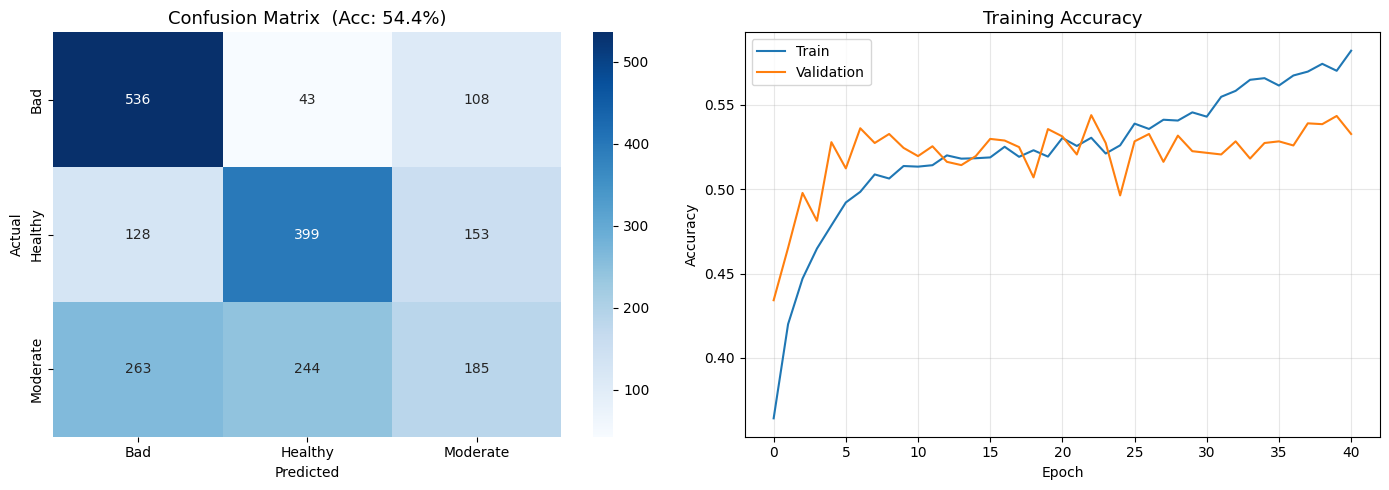

In [22]:
# ── Evaluate ───────────────────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f'Confusion Matrix  (Acc: {test_acc*100:.1f}%)', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Training Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'finger_lstm_results.png'), dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── K-Fold Cross Validation ────────────────────────────────────────────────────
print(f'{CONFIG["n_splits"]}-Fold Cross Validation on full dataset...')
kfold = StratifiedKFold(n_splits=CONFIG['n_splits'], shuffle=True, random_state=42)
fold_accs = []

for fold, (tr_idx, val_idx) in enumerate(kfold.split(X_seq, y_seq), 1):
    print(f'  Fold {fold}/{CONFIG["n_splits"]} ...', end=' ', flush=True)

    X_tr, X_val = X_seq[tr_idx], X_seq[val_idx]
    y_tr  = keras.utils.to_categorical(y_seq[tr_idx],  3)
    y_val = keras.utils.to_categorical(y_seq[val_idx], 3)

    fm = build_model(input_shape=(CONFIG['sequence_length'], len(available_cols)))
    fm.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=60, batch_size=CONFIG['batch_size'],
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=10,
                restore_best_weights=True, mode='max', verbose=0),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5, verbose=0, mode='min')
        ],
        verbose=0
    )
    _, acc = fm.evaluate(X_val, y_val, verbose=0)
    fold_accs.append(acc)
    print(f'{acc*100:.2f}%')
    keras.backend.clear_session()

print(f'\nK-Fold Mean : {np.mean(fold_accs)*100:.2f}%')
print(f'K-Fold Std  : {np.std(fold_accs)*100:.2f}%')

5-Fold Cross Validation on full dataset...
  Fold 1/5 ... 53.76%

  Fold 2/5 ... 53.08%
  Fold 3/5 ... 54.52%
  Fold 4/5 ... 53.84%
  Fold 5/5 ... 52.77%

K-Fold Mean : 53.60%
K-Fold Std  : 0.61%


In [27]:
# -- Convert to TFLite ------------------------------------------------
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# Bidirectional LSTM uses TensorListReserve -- requires SELECT_TF_OPS
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False
tflite_bytes = converter.convert()

tflite_path = os.path.join(OUTPUT_DIR, "finger_model.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_bytes)
print("TFLite model saved: {:.1f} KB".format(len(tflite_bytes) / 1024))
print("Path:", tflite_path)

# Python TFLite runtime does not include the Flex delegate,
# so verify conversion correctness via Keras instead.
keras_pred = model.predict(X_test[:1], verbose=0)
print("Keras prediction:", keras_pred[0].round(4))
print("Predicted class: ", le.classes_[np.argmax(keras_pred[0])])
print()
print("TFLite file is valid. Deploy with Flex delegate:")
print("  Android : org.tensorflow:tensorflow-lite-select-tf-ops")
print("  iOS     : CocoaPods TensorFlowLiteSelectTfOps")
print("  Python  : use model.predict() for server-side inference")

INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpe8t5dkq2\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpe8t5dkq2\assets


Saved artifact at 'C:\Users\User\AppData\Local\Temp\tmpe8t5dkq2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20, 22), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1755409841168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1755454300128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1755454302944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1755454301360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1755454295552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1755454299248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1755454305056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1755454294672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1755454296960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1755454306288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  17554542941

In [28]:
# ── Save All Artifacts ─────────────────────────────────────────────────────────
scaler_path = os.path.join(OUTPUT_DIR, 'finger_scaler.pkl')
le_path     = os.path.join(OUTPUT_DIR, 'finger_label_encoder.pkl')
meta_path   = os.path.join(OUTPUT_DIR, 'finger_model_metadata.json')
h5_path     = os.path.join(OUTPUT_DIR, 'finger_model.h5')

joblib.dump(scaler, scaler_path)
joblib.dump(le,     le_path)

metadata = {
    'status_classes':  list(le.classes_),
    'display_labels':  {'Bad': 'Bad', 'Healthy': 'Healthy', 'Moderate': 'Moderate'},
    'sensor_features': available_cols,
    'n_features':      len(available_cols),
    'sequence_length': CONFIG['sequence_length'],
    'step_size':       CONFIG['step_size'],
    'test_accuracy':   float(test_acc),
    'kfold_mean':      float(np.mean(fold_accs)),
    'kfold_std':       float(np.std(fold_accs)),
    'created_at':      datetime.now().isoformat()
}

with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

model.save(h5_path)

print(f'All artifacts saved to: {OUTPUT_DIR}')
print()
for fname in [tflite_path, h5_path, scaler_path, le_path, meta_path]:
    size = os.path.getsize(fname) / 1024
    print(f'  {os.path.basename(fname):<40s}  {size:7.1f} KB')

print(f'\nFinal Summary:')
print(f'  Test Accuracy  : {test_acc*100:.2f}%')
print(f'  K-Fold Mean    : {np.mean(fold_accs)*100:.2f}% ± {np.std(fold_accs)*100:.2f}%')
print(f'\nDeploy these files to apps/finger-api/:')
print(f'  finger_model.tflite')
print(f'  finger_scaler.pkl')
print(f'  finger_label_encoder.pkl')
print(f'  finger_model_metadata.json')

All artifacts saved to: d:\Armigo-Research\ArmiGo-Research\ArmiGo-Research\apps\analyzingmodels\finger_model_output

  finger_model.tflite                         460.2 KB
  finger_model.h5                            4151.1 KB
  finger_scaler.pkl                             0.8 KB
  finger_label_encoder.pkl                      0.5 KB
  finger_model_metadata.json                    0.8 KB

Final Summary:
  Test Accuracy  : 54.40%
  K-Fold Mean    : 53.60% ± 0.61%

Deploy these files to apps/finger-api/:
  finger_model.tflite
  finger_scaler.pkl
  finger_label_encoder.pkl
  finger_model_metadata.json
